# PEARL THAKKAR - KAGGLE PROJECT!

In [1]:
## Dataset: Mushroom Classificiation (https://www.kaggle.com/datasets/uciml/mushroom-classification/data)

In [2]:
## The challenge in this project is to find out whether a mushroom is edible or poisonous by studying it's characteristics.
## The central question is to determine which feature is the most relaible for telling whether a mushroom is edible or
## poisonous. 

## This dataset contains records of 8124 mushrooms, a column for class (for telling us if the mushroom is edible (e) or 
## poisonous (p)), and 22 mushroom characteristics containing categorical data.

In [3]:
## I first loaded the data set into a pandas dataframe
## This is important to understand the data structure, and check if its read correctly
## I checked the no. of rows and columns, sample records, feature names, and target column

In [4]:
import pandas as pd

df = pd.read_csv("mushrooms.csv") ## loading dataset

## initial look at the data
print("Shape of dataset:", df.shape)  ## size of table: (rows, columns)

print("\nNumber of rows:", df.shape[0]) ## no. of rows
print("Number of columns:", df.shape[1]) ## no. of columns

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

Shape of dataset: (8124, 23)

Number of rows: 8124
Number of columns: 23

Column Names:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

First 5 Rows:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n 

In [36]:
print(df.info()) ## for a summary

print("\nMissing Values in Each Column:")
print(df.isnull().sum()) ## to check for how many missing values there are in each column, if any

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [6]:
print(df["class"].value_counts()) ## to check if there's any class imbalance between edible and poisonous

class
e    4208
p    3916
Name: count, dtype: int64


In [7]:
for col in df.columns: 
    if "?" in df[col].unique(): ## for checking for the presence of '?' in each column
        print(col, df[col].value_counts()["?"]) 

stalk-root 2480


In [11]:
## since its a categorical data set with no numbers there aren't any null values in the traditional sense, but 
## we know now that the column 'stalk-root' has a '?'(unknown/missing value) 2480 times

In [8]:
for col in df.columns:
    print(col, ":", sorted(df[col].unique())) ## for checking all the possible values in each column(since it's not numbers)

class : ['e', 'p']
cap-shape : ['b', 'c', 'f', 'k', 's', 'x']
cap-surface : ['f', 'g', 's', 'y']
cap-color : ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises : ['f', 't']
odor : ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment : ['a', 'f']
gill-spacing : ['c', 'w']
gill-size : ['b', 'n']
gill-color : ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape : ['e', 't']
stalk-root : ['?', 'b', 'c', 'e', 'r']
stalk-surface-above-ring : ['f', 'k', 's', 'y']
stalk-surface-below-ring : ['f', 'k', 's', 'y']
stalk-color-above-ring : ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
stalk-color-below-ring : ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
veil-type : ['p']
veil-color : ['n', 'o', 'w', 'y']
ring-number : ['n', 'o', 't']
ring-type : ['e', 'f', 'l', 'n', 'p']
spore-print-color : ['b', 'h', 'k', 'n', 'o', 'r', 'u', 'w', 'y']
population : ['a', 'c', 'n', 's', 'v', 'y']
habitat : ['d', 'g', 'l', 'm', 'p', 'u', 'w']


In [9]:
## from this we have found that all mushrooms are of the same veil type (p) so that column is irrelevant for us

In [10]:
for col in df.columns:
    
    if col != "class":
        print("\nFEATURE:", col)
        print(pd.crosstab(df[col], df["class"]))


FEATURE: cap-shape
class         e     p
cap-shape            
b           404    48
c             0     4
f          1596  1556
k           228   600
s            32     0
x          1948  1708

FEATURE: cap-surface
class           e     p
cap-surface            
f            1560   760
g               0     4
s            1144  1412
y            1504  1740

FEATURE: cap-color
class         e     p
cap-color            
b            48   120
c            32    12
e           624   876
g          1032   808
n          1264  1020
p            56    88
r            16     0
u            16     0
w           720   320
y           400   672

FEATURE: bruises
class       e     p
bruises            
f        1456  3292
t        2752   624

FEATURE: odor
class     e     p
odor             
a       400     0
c         0   192
f         0  2160
l       400     0
m         0    36
n      3408   120
p         0   256
s         0   576
y         0   576

FEATURE: gill-attachment
class            

In [11]:
## I did this to check if any single feature can strongly separate edible and poisonous mushrooms 
## before using machine learning models.

## I think the strongest feature was odor, followed by stalk-surface-above-ring and stalk-surface-below-ring.

## The odor categories perfectly fit one class:
## odor = c,f,m,p,s,y are poisonous only
## odor = a and l are edible only
## so we can say that odor can potentially play a big role in identifying edible and poisonous mushrooms.

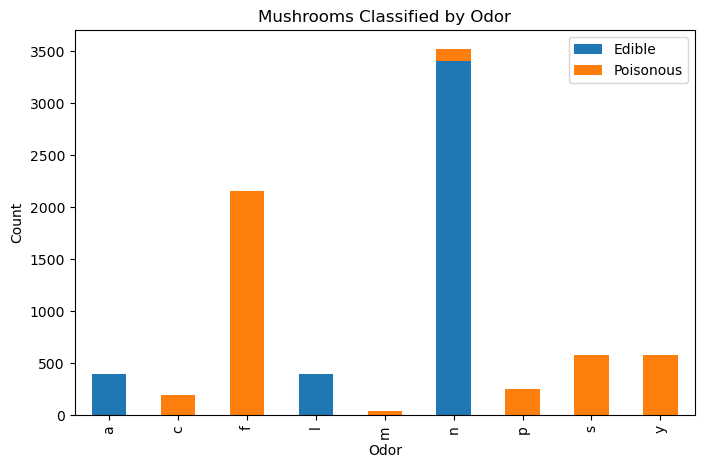

In [12]:
import matplotlib.pyplot as plt

pd.crosstab(df["odor"], df["class"]).plot(kind="bar", stacked=True, figsize=(8,5))  ## making a bar plot for visualizing

plt.title("Mushrooms Classified by Odor")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.legend(["Edible", "Poisonous"])
plt.show()

In [13]:
## only n has a mix of both edible and poisonous mushrooms, but otherwise odor seems to be very useful for classification.

In [14]:
def OdorBase(x): ## for establishing a baseline using only the odor feature
    if x in ['c','f','m','p','s','y']:
        return 'p'
    elif x in ['a','l']:
        return 'e'
    else:
        return 'e'   ## since n is mostly edible

df["odor_prediction"] = df["odor"].apply(OdorBase)

accuracy = (df["odor_prediction"] == df["class"]).mean()

print("Baseline Accuracy =", round(accuracy*100,2), "%") ## calculating basline

Baseline Accuracy = 98.52 %


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop(columns=["class", "odor_prediction"])
y = df["class"]

## for making categories into binary columns (for Logistic Regression)

## splittingX = pd.get_dummies(X) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## training the model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

## predict
y_pred = model.predict(X_test)

## accuracy
acc = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy =", round(acc*100,2), "%")

Logistic Regression Accuracy = 100.0 %


In [16]:
## The logistic regression accuracy came out to be 100% for the data we tested
## This suggests the mushroom dataset has very clear patterns.
## The mushroom features separate edible and poisonous classes very well.

## For better visualization, we can use a Decision Tree as it works well for tabular data

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## training decision tree on the same data as linear regression
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

## predict
tree_pred = tree_model.predict(X_test)

## accuracy
tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy =", round(tree_acc*100,2), "%")

Decision Tree Accuracy = 100.0 %


In [18]:
## From this we can basically say that the data is very predictable since we got:
## Odor Rule Baseline = 98.52%
## Logistic Regression Accuracy = 100.0 %
## Decision Tree Accuracy = 100.0 %
## Even though we see 100% test accuracies, in real world it will alost never be the case

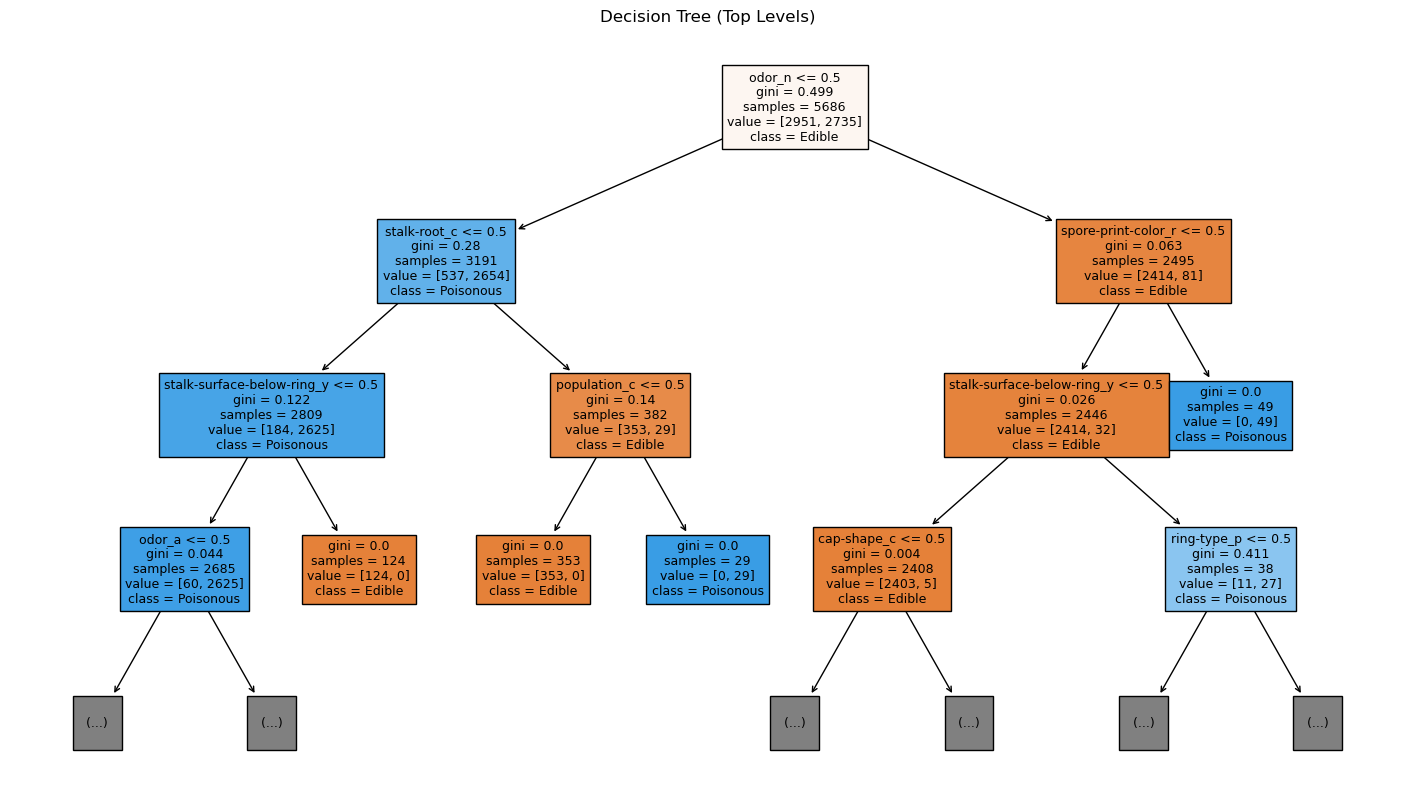

In [19]:
## plotting the top levels of the decision tree to help explain which characteristics are most important for classification.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    tree_model,
    filled=True,
    feature_names=X.columns,
    class_names=["Edible","Poisonous"],
    max_depth=3, ## to focus on just the top levels that show the most important information 
    fontsize=9)

plt.title("Decision Tree (Top Levels)")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## creating a random forest with only one tree
rf_single = RandomForestClassifier(n_estimators = 1, random_state = 42)

## training the model
rf_single.fit(X_train, y_train)

## making predictions
single_tree_pred = rf_single.predict(X_test)

## checking accuracy
print("Single Tree Accuracy:", accuracy_score(y_test, single_tree_pred))

Single Tree Accuracy: 0.9991796554552912


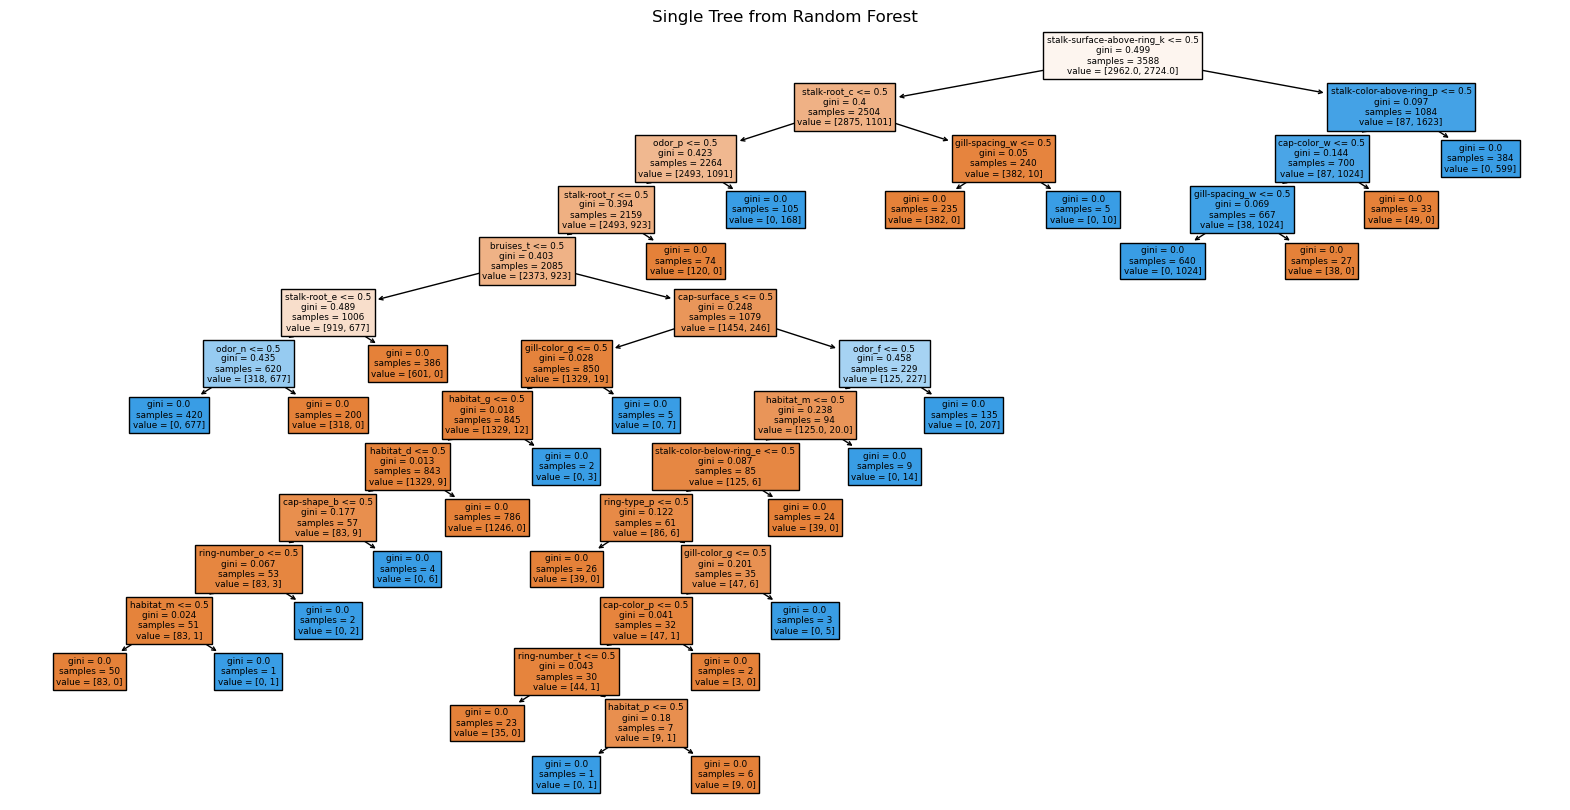

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

## plotting the single tree inside the random forest
plt.figure(figsize=(20,10))
plot_tree(
    rf_single.estimators_[0], ## this gives us the only tree in the forest
    filled=True, 
    feature_names=X.columns)

plt.title("Single Tree from Random Forest")
plt.show()

In [25]:
## manual rule based on the important feature (odor) mimicing what the decision tree learned
def mushroom_rule(row):    
    ## if odor = 'n' (no smell), mostly edible
    if row['odor_n'] == 1:
        return 'e'
    
    ## if odor = 'f' (foul), poisonous
    elif row['odor_f'] == 1:
        return 'p'
    
    ## if odor = 'c' (creosote aka desert-like earthy), poisonous
    elif row['odor_c'] == 1:
        return 'p'
    
    ## default case (remaining odors mostly edible)
    else:
        return 'e'

In [38]:
## appling rule to test data
manual_preds = X_test.apply(mushroom_rule, axis=1)

## calculating accuracy
manual_accuracy = (manual_preds == y_test).mean()

print("Manual Tree Accuracy:", round(manual_accuracy * 100, 2), "%")

Manual Tree Accuracy: 80.23 %


In [ ]:
## I implemented a manual rule-based function using if-else statements to approximate the logic of the decision tree.
## This manual approach achieved lower accuracy (80.23%) compared to the trained models.

## I think this shows that while simple rules can capture some patterns, the full decision tree uses a combination of 
## multiple features to achieve perfect classification.

## So the manual rule was just a simplified approximation and doesn't fully represent the complete decision tree logic.

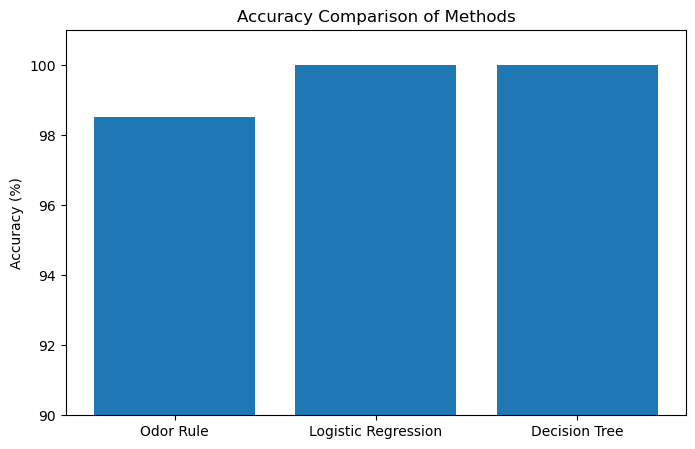

In [39]:
## Now, comparing all the test accuracies for better visualization

import matplotlib.pyplot as plt

methods = ["Odor Rule", "Logistic Regression", "Decision Tree"]
scores = [98.52, 100.0, 100.0]

plt.figure(figsize=(8,5))
plt.bar(methods, scores)

plt.title("Accuracy Comparison of Methods")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 101)

plt.show()

In [ ]:
## Here, I compared all the methods used in this project
## We can see that the Odor Baseline already gave us a 98.52 % accuracy, which was a good enough test to depict odor to be
## an extremely strong recognizing factor in finding whether a mushroom is edible or poisonous.

## Logistic Regression and Decision Tree both achieved 100% accuracy, 
## depicting that combining multiple mushroom features gives perfect classification on this test split.

## So although machine learning models performed best, the odor baseline was simpler and still highly effective.

In [ ]:
## Conclusion:

## The goal of this project was to determine whether a mushroom is edible or poisonous using its characteristics.

## After lookng through the data, I found that odor was the most relaible single feature.

## A simple odor-based rule classified mushrooms with 98.52% accuracy.

## Logistic Regression and Decision Tree both reached 100% accuracy.

## This tells us that this mushroom dataset is highly structured and separable, with clear feature patterns 
## that can help distinguish edible and poisonous mushrooms easily.
